In [4]:
import sys
print(sys.executable)

c:\Users\engma\anaconda3\envs\py310env\python.exe


In [ ]:
%pip install torch

In [1]:
from pathlib import Path
import numpy as np

prepared_file = Path("data/processed/training_sequences.npz")
cloud_file = Path(
    "data/raw/satellite/ireland_clouds_20240101_20250101.npz"
)

with np.load(prepared_file) as prepared:
    print("Saved arrays:", prepared.files)
    print("Image positions:", prepared["image_positions"].shape)
    print("Weather inputs:", prepared["weather"].shape)
    print("Rainfall targets:", prepared["rain"].shape)
    print("Training examples:", len(prepared["train_rows"]))
    print("Validation examples:", len(prepared["validation_rows"]))
    print("Test examples:", len(prepared["test_rows"]))

print("Cloud file found:", cloud_file.exists())

Saved arrays: ['image_positions', 'weather', 'rain', 'train_rows', 'validation_rows', 'test_rows', 'weather_mean', 'weather_std', 'station_names']
Image positions: (8778, 6)
Weather inputs: (8778, 6, 10)
Rainfall targets: (8778, 5)
Training examples: 6136
Validation examples: 1315
Test examples: 1315
Cloud file found: True


In [2]:
with np.load(prepared_file) as prepared:
    image_positions = prepared["image_positions"]
    weather = prepared["weather"]
    rain = prepared["rain"]

    train_rows = prepared["train_rows"]
    validation_rows = prepared["validation_rows"]
    test_rows = prepared["test_rows"]

with np.load(cloud_file) as clouds:
    cloud_masks = clouds["cloud_mask"]

print("Hourly cloud masks:", cloud_masks.shape)
print("One training example uses images:", image_positions[train_rows[0]])

Hourly cloud masks: (8784, 90, 120)
One training example uses images: [0 1 2 3 4 5]


In [6]:
import torch
from torch.utils.data import Dataset

class RainfallDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]

        # Six cloud masks, reduced from 90×120 to 45×60
        masks = cloud_masks[image_positions[row], ::2, ::2]

        cloud = (masks == 2).astype(np.float32)
        valid = (masks != 3).astype(np.float32)

        # PyTorch CNN expects channels before height and width:
        # (6 hours, 2 channels, 45 rows, 60 columns)
        images = np.stack([cloud, valid], axis=1)

        station_inputs = weather[row]  # (6 hours, 10 values)
        rainfall = rain[row]           # (5 stations)

        return (
            torch.from_numpy(images),
            torch.from_numpy(station_inputs),
            torch.from_numpy(rainfall),
        )

train_dataset = RainfallDataset(train_rows)

example_images, example_weather, example_rain = train_dataset[0]

print("Images:", example_images.shape)
print("Station inputs:", example_weather.shape)
print("Rainfall target:", example_rain.shape)

Images: torch.Size([6, 2, 45, 60])
Station inputs: torch.Size([6, 10])
Rainfall target: torch.Size([5])


In [7]:
from torch.utils.data import DataLoader

validation_dataset = RainfallDataset(validation_rows)
test_dataset = RainfallDataset(test_rows)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

batch_images, batch_weather, batch_rain = next(iter(train_loader))

print("Batch images:", batch_images.shape)
print("Batch station inputs:", batch_weather.shape)
print("Batch rainfall targets:", batch_rain.shape)

Batch images: torch.Size([16, 6, 2, 45, 60])
Batch station inputs: torch.Size([16, 6, 10])
Batch rainfall targets: torch.Size([16, 5])


In [8]:
import torch.nn as nn

class CloudRainModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Turn one cloud map into 32 learned features
        self.cnn = nn.Sequential(
            nn.Conv2d(2, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, 32),
            nn.ReLU()
        )

        # Each hour has 32 image features + 10 station measurements
        self.lstm = nn.LSTM(
            input_size=32 + 10,
            hidden_size=32,
            batch_first=True
        )

        # Predict rainfall at five stations
        self.output = nn.Linear(32, 5)
        self.non_negative = nn.Softplus()

    def forward(self, images, station_inputs):
        batch_size, hours, channels, height, width = images.shape

        # Process all images with the same CNN
        images = images.reshape(batch_size * hours, channels, height, width)
        image_features = self.cnn(images)
        image_features = image_features.reshape(batch_size, hours, 32)

        # Join image features and measurements at each hour
        hourly_features = torch.cat(
            [image_features, station_inputs],
            dim=2
        )

        sequence_output, _ = self.lstm(hourly_features)

        # Use the final hour to predict the following hour
        last_hour = sequence_output[:, -1, :]
        rainfall = self.non_negative(self.output(last_hour))

        return rainfall

model = CloudRainModel()

# Check that one batch passes through the model
with torch.no_grad():
    predictions = model(batch_images, batch_weather)

print("Predictions:", predictions.shape)
print("Targets:", batch_rain.shape)

Predictions: torch.Size([16, 5])
Targets: torch.Size([16, 5])


In [9]:
loss_function = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model.train()

# 1. Clear gradients from any previous update
optimizer.zero_grad()

# 2. Predict rainfall for this batch
predictions = model(batch_images, batch_weather)

# 3. Measure the difference from recorded rainfall
loss = loss_function(predictions, batch_rain)

# 4. Calculate gradients and update the model
loss.backward()
optimizer.step()

print("Loss after one training batch:", loss.item())

Loss after one training batch: 0.2489066869020462


In [12]:
from pathlib import Path

epochs = 10
best_validation_loss = float("inf")
history = []

models_folder = Path("models")
models_folder.mkdir(exist_ok=True)
model_file = models_folder / "best_cloud_rain_model.pt"

for epoch in range(1, epochs + 1):
    # Training
    model.train()
    training_loss_total = 0

    for images, station_inputs, targets in train_loader:
        optimizer.zero_grad()

        predictions = model(images, station_inputs)
        loss = loss_function(predictions, targets)

        loss.backward()
        optimizer.step()

        training_loss_total += loss.item() * len(targets)

    training_loss = training_loss_total / len(train_dataset)

    # Validation
    model.eval()
    validation_loss_total = 0

    with torch.no_grad():
        for images, station_inputs, targets in validation_loader:
            predictions = model(images, station_inputs)
            loss = loss_function(predictions, targets)

            validation_loss_total += loss.item() * len(targets)

    validation_loss = validation_loss_total / len(validation_dataset)

    history.append((training_loss, validation_loss))

    print(
        f"Epoch {epoch}/{epochs} | "
        f"Training loss: {training_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f}",
        flush=True
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        torch.save(model.state_dict(), model_file)
        print(f"  Saved best model to {model_file}", flush=True)

Epoch 1/10 | Training loss: 0.0515 | Validation loss: 0.0581
  Saved best model to models\best_cloud_rain_model.pt
Epoch 2/10 | Training loss: 0.0506 | Validation loss: 0.0566
  Saved best model to models\best_cloud_rain_model.pt
Epoch 3/10 | Training loss: 0.0497 | Validation loss: 0.0557
  Saved best model to models\best_cloud_rain_model.pt
Epoch 4/10 | Training loss: 0.0489 | Validation loss: 0.0561
Epoch 5/10 | Training loss: 0.0482 | Validation loss: 0.0556
  Saved best model to models\best_cloud_rain_model.pt
Epoch 6/10 | Training loss: 0.0474 | Validation loss: 0.0562
Epoch 7/10 | Training loss: 0.0469 | Validation loss: 0.0570
Epoch 8/10 | Training loss: 0.0460 | Validation loss: 0.0556
  Saved best model to models\best_cloud_rain_model.pt
Epoch 9/10 | Training loss: 0.0461 | Validation loss: 0.0560
Epoch 10/10 | Training loss: 0.0447 | Validation loss: 0.0557


In [13]:
max_epochs = 30
patience = 5

# Keep the best result from the first five epochs
best_validation_loss = min(val_loss for _, val_loss in history)
epochs_without_improvement = 0
next_epoch = len(history) + 1

for epoch in range(next_epoch, max_epochs + 1):
    model.train()
    training_loss_total = 0

    for images, station_inputs, targets in train_loader:
        optimizer.zero_grad()

        predictions = model(images, station_inputs)
        loss = loss_function(predictions, targets)

        loss.backward()
        optimizer.step()

        training_loss_total += loss.item() * len(targets)

    training_loss = training_loss_total / len(train_dataset)

    model.eval()
    validation_loss_total = 0

    with torch.no_grad():
        for images, station_inputs, targets in validation_loader:
            predictions = model(images, station_inputs)
            loss = loss_function(predictions, targets)

            validation_loss_total += loss.item() * len(targets)

    validation_loss = validation_loss_total / len(validation_dataset)
    history.append((training_loss, validation_loss))

    print(
        f"Epoch {epoch}/{max_epochs} | "
        f"Training loss: {training_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f}",
        flush=True
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_file)
        print("  New best model saved.", flush=True)
    else:
        epochs_without_improvement += 1
        print(
            f"  No improvement: {epochs_without_improvement}/{patience}",
            flush=True
        )

    if epochs_without_improvement >= patience:
        print("Stopped early: validation loss did not improve.")
        break

print(f"Best validation loss: {best_validation_loss:.4f}")
print("Saved model:", model_file)

Epoch 11/30 | Training loss: 0.0439 | Validation loss: 0.0562
  No improvement: 1/5
Epoch 12/30 | Training loss: 0.0433 | Validation loss: 0.0572
  No improvement: 2/5
Epoch 13/30 | Training loss: 0.0427 | Validation loss: 0.0570
  No improvement: 3/5
Epoch 14/30 | Training loss: 0.0419 | Validation loss: 0.0567
  No improvement: 4/5
Epoch 15/30 | Training loss: 0.0416 | Validation loss: 0.0570
  No improvement: 5/5
Stopped early: validation loss did not improve.
Best validation loss: 0.0556
Saved model: models\best_cloud_rain_model.pt


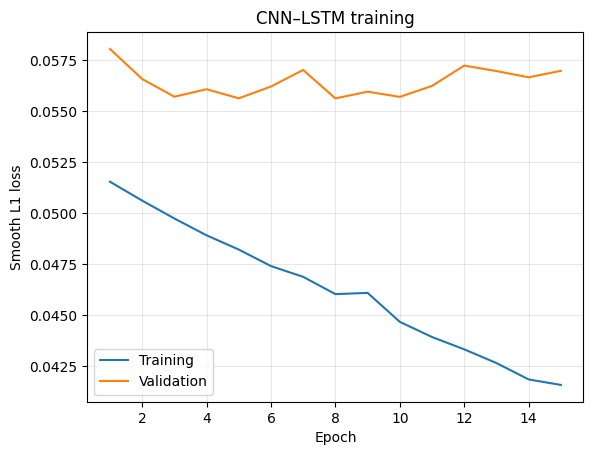

In [14]:
import matplotlib.pyplot as plt

training_losses = [train_loss for train_loss, _ in history]
validation_losses = [val_loss for _, val_loss in history]
epoch_numbers = range(1, len(history) + 1)

plt.plot(epoch_numbers, training_losses, label="Training")
plt.plot(epoch_numbers, validation_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Smooth L1 loss")
plt.title("CNN–LSTM training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
# Load the weights from the best validation epoch
best_model = CloudRainModel()
best_model.load_state_dict(
    torch.load(model_file, map_location="cpu", weights_only=True)
)
best_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for images, station_inputs, targets in test_loader:
        predictions = best_model(images, station_inputs)
        all_predictions.append(predictions)
        all_targets.append(targets)

test_predictions = torch.cat(all_predictions)
test_targets = torch.cat(all_targets)

model_loss = loss_function(test_predictions, test_targets).item()
dry_baseline = torch.zeros_like(test_targets)
baseline_loss = loss_function(dry_baseline, test_targets).item()

print(f"Model test loss:         {model_loss:.4f}")
print(f"Always-zero test loss:   {baseline_loss:.4f}")

Model test loss:         0.0592
Always-zero test loss:   0.0728


In [16]:
errors = test_predictions - test_targets
rainy = test_targets > 0

mae = errors.abs().mean()
rmse = torch.sqrt((errors ** 2).mean())
rainy_mae = errors[rainy].abs().mean()

baseline_mae = test_targets.abs().mean()
baseline_rainy_mae = test_targets[rainy].abs().mean()

print(f"Rainy station-hours: {rainy.sum().item()} of {rainy.numel()}")
print(f"Model MAE:             {mae.item():.3f} mm")
print(f"Always-zero MAE:       {baseline_mae.item():.3f} mm")
print(f"Model RMSE:            {rmse.item():.3f} mm")
print(f"Model MAE when rainy:  {rainy_mae.item():.3f} mm")
print(f"Zero MAE when rainy:   {baseline_rainy_mae.item():.3f} mm")

Rainy station-hours: 1409 of 6575
Model MAE:             0.155 mm
Always-zero MAE:       0.129 mm
Model RMSE:            0.469 mm
Model MAE when rainy:  0.457 mm
Zero MAE when rainy:   0.604 mm


In [17]:
with np.load(prepared_file) as prepared:
    station_names = prepared["station_names"]

for station_index, name in enumerate(station_names):
    actual = test_targets[:, station_index]
    predicted = test_predictions[:, station_index]
    rainy_hours = actual > 0

    station_mae = (predicted - actual).abs().mean()
    rainy_mae = (predicted[rainy_hours] - actual[rainy_hours]).abs().mean()

    print(
        f"{name}: MAE {station_mae.item():.3f} mm | "
        f"rainy-hour MAE {rainy_mae.item():.3f} mm | "
        f"rainy hours {rainy_hours.sum().item()}"
    )

Casement: MAE 0.109 mm | rainy-hour MAE 0.452 mm | rainy hours 178
Cork: MAE 0.176 mm | rainy-hour MAE 0.429 mm | rainy hours 364
Shannon: MAE 0.163 mm | rainy-hour MAE 0.457 mm | rainy hours 307
Knock: MAE 0.214 mm | rainy-hour MAE 0.480 mm | rainy hours 405
Dublin: MAE 0.112 mm | rainy-hour MAE 0.472 mm | rainy hours 155


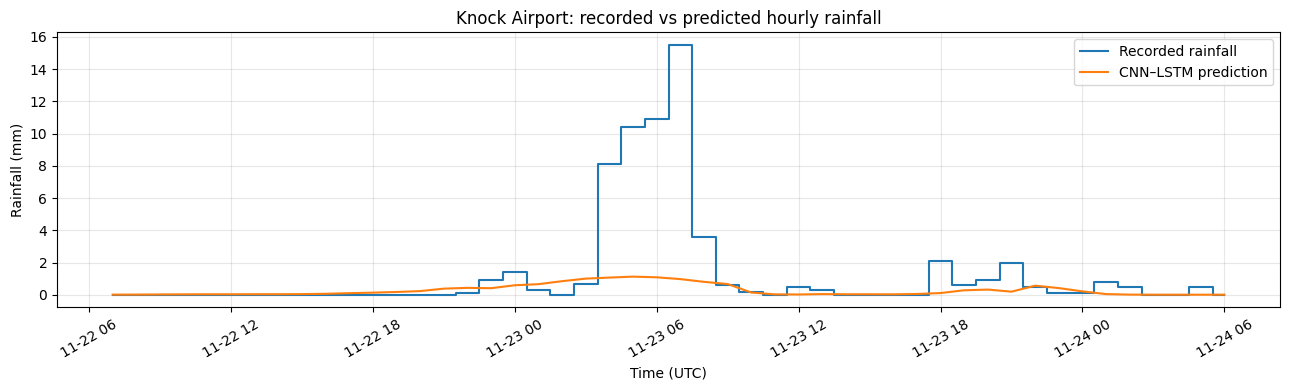

In [18]:
station_index = 3  # Knock: Casement=0, Cork=1, Shannon=2, Knock=3, Dublin=4

observed = test_targets[:, station_index].numpy()
predicted = test_predictions[:, station_index].numpy()

# Find the largest recorded rainfall hour, then show nearby hours
peak_hour = np.argmax(observed)
start = max(0, peak_hour - 24)
end = min(len(observed), start + 48)

# Recover the timestamps for the test targets
with np.load(cloud_file) as cloud_data:
    all_times = cloud_data["times"]

test_times = all_times[test_rows + 6]

plt.figure(figsize=(13, 4))
plt.step(
    test_times[start:end],
    observed[start:end],
    where="mid",
    label="Recorded rainfall"
)
plt.plot(
    test_times[start:end],
    predicted[start:end],
    label="CNN–LSTM prediction"
)

plt.title("Knock Airport: recorded vs predicted hourly rainfall")
plt.ylabel("Rainfall (mm)")
plt.xlabel("Time (UTC)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [19]:
heavy_rain = test_targets >= 2.0

print("Station-hours with at least 2 mm rain:", heavy_rain.sum().item())

print(
    "Average recorded amount:",
    f"{test_targets[heavy_rain].mean().item():.2f} mm"
)
print(
    "Average predicted amount:",
    f"{test_predictions[heavy_rain].mean().item():.2f} mm"
)
print(
    "MAE during these hours:",
    f"{(test_predictions[heavy_rain] - test_targets[heavy_rain]).abs().mean().item():.2f} mm"
)

Station-hours with at least 2 mm rain: 94
Average recorded amount: 3.26 mm
Average predicted amount: 0.50 mm
MAE during these hours: 2.76 mm


In [20]:
for name, rows in [
    ("Training", train_rows),
    ("Validation", validation_rows),
    ("Test", test_rows),
]:
    amounts = rain[rows]  # Five station rainfall values per example
    heavy = amounts >= 2.0

    print(
        f"{name}: {heavy.sum()} heavy-rain station-hours "
        f"out of {amounts.size} "
        f"({100 * heavy.mean():.2f}%)"
    )

Training: 364 heavy-rain station-hours out of 30680 (1.19%)
Validation: 86 heavy-rain station-hours out of 6575 (1.31%)
Test: 94 heavy-rain station-hours out of 6575 (1.43%)


In [21]:
# How often does it rain at the five stations?
for name, rows in [
    ("Training", train_rows),
    ("Validation", validation_rows),
    ("Test", test_rows),
]:
    station_hours = rain[rows]
    rainy_hours = (station_hours > 0).sum()
    total_hours = station_hours.size

    print(
        f"{name}: {rainy_hours} rainy station-hours "
        f"out of {total_hours} "
        f"({100 * rainy_hours / total_hours:.1f}%)"
    )

Training: 5568 rainy station-hours out of 30680 (18.1%)
Validation: 1022 rainy station-hours out of 6575 (15.5%)
Test: 1409 rainy station-hours out of 6575 (21.4%)


In [22]:
# 1 means rain was recorded; 0 means no rain was recorded.
rain_labels = (rain > 0).astype(np.float32)

print("Rainfall amounts shape:", rain.shape)
print("Rain/no-rain labels shape:", rain_labels.shape)
print("First hour, five stations:", rain_labels[0])

Rainfall amounts shape: (8778, 5)
Rain/no-rain labels shape: (8778, 5)
First hour, five stations: [0. 0. 0. 1. 0.]


In [23]:
from torch.utils.data import Dataset

class RainOccurrenceDataset(Dataset):
    def __init__(self, rainfall_dataset):
        self.rainfall_dataset = rainfall_dataset

    def __len__(self):
        return len(self.rainfall_dataset)

    def __getitem__(self, index):
        images, station_inputs, rainfall = self.rainfall_dataset[index]

        # Convert rainfall in mm to five rain/no-rain labels.
        rain_labels = (rainfall > 0).float()

        return images, station_inputs, rain_labels


rain_train_dataset = RainOccurrenceDataset(train_dataset)

images, station_inputs, labels = rain_train_dataset[0]
print("Cloud images:", images.shape)
print("Station inputs:", station_inputs.shape)
print("Rain/no-rain labels:", labels)

Cloud images: torch.Size([6, 2, 45, 60])
Station inputs: torch.Size([6, 10])
Rain/no-rain labels: tensor([0., 0., 0., 1., 0.])


In [24]:
from torch.utils.data import DataLoader

rain_validation_dataset = RainOccurrenceDataset(validation_dataset)

rain_train_loader = DataLoader(
    rain_train_dataset,
    batch_size=16,
    shuffle=True
)

rain_validation_loader = DataLoader(
    rain_validation_dataset,
    batch_size=16,
    shuffle=False
)

batch_images, batch_weather, batch_labels = next(iter(rain_train_loader))

print("Batch images:", batch_images.shape)
print("Batch station inputs:", batch_weather.shape)
print("Batch rain/no-rain labels:", batch_labels.shape)

Batch images: torch.Size([16, 6, 2, 45, 60])
Batch station inputs: torch.Size([16, 6, 10])
Batch rain/no-rain labels: torch.Size([16, 5])


In [25]:
# Rainfall categories for each station-hour
# 0: dry                 0 mm
# 1: light               more than 0, less than 0.5 mm
# 2: moderate            0.5 to less than 2 mm
# 3: higher rainfall     2 mm or more

rain_classes = np.zeros(rain.shape, dtype=np.int64)

rain_classes[(rain > 0) & (rain < 0.5)] = 1
rain_classes[(rain >= 0.5) & (rain < 2)] = 2
rain_classes[rain >= 2] = 3

class_names = ["Dry", "Light", "Moderate", "Higher rainfall"]

for number, name in enumerate(class_names):
    count = (rain_classes[train_rows] == number).sum()
    print(f"{name}: {count} training station-hours")

Dry: 25112 training station-hours
Light: 3369 training station-hours
Moderate: 1835 training station-hours
Higher rainfall: 364 training station-hours


In [26]:
class RainIntensityDataset(Dataset):
    def __init__(self, rainfall_dataset):
        self.rainfall_dataset = rainfall_dataset

    def __len__(self):
        return len(self.rainfall_dataset)

    def __getitem__(self, index):
        images, station_inputs, rainfall = self.rainfall_dataset[index]

        categories = torch.zeros_like(rainfall, dtype=torch.long)
        categories[(rainfall > 0) & (rainfall < 0.5)] = 1
        categories[(rainfall >= 0.5) & (rainfall < 2)] = 2
        categories[rainfall >= 2] = 3

        return images, station_inputs, categories


intensity_train_dataset = RainIntensityDataset(train_dataset)

images, station_inputs, categories = intensity_train_dataset[0]
print("Category numbers:", categories)
print("Target shape:", categories.shape)
print("Target type:", categories.dtype)

Category numbers: tensor([0, 0, 0, 1, 0])
Target shape: torch.Size([5])
Target type: torch.int64


In [27]:
intensity_validation_dataset = RainIntensityDataset(validation_dataset)

intensity_train_loader = DataLoader(
    intensity_train_dataset,
    batch_size=16,
    shuffle=True
)

intensity_validation_loader = DataLoader(
    intensity_validation_dataset,
    batch_size=16,
    shuffle=False
)

batch_images, batch_weather, batch_categories = next(
    iter(intensity_train_loader)
)

print("Images:", batch_images.shape)
print("Weather:", batch_weather.shape)
print("Categories:", batch_categories.shape)
print("First example:", batch_categories[0])

Images: torch.Size([16, 6, 2, 45, 60])
Weather: torch.Size([16, 6, 10])
Categories: torch.Size([16, 5])
First example: tensor([0, 2, 0, 0, 0])
